In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e9/sample_submission.csv
/kaggle/input/playground-series-s5e9/train.csv
/kaggle/input/playground-series-s5e9/test.csv


In [2]:
train_data = pd.read_csv("/kaggle/input/playground-series-s5e9/train.csv", index_col=0)

In [3]:
train_data.head(20)

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
id,,,,,,,,,,
0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511
5,0.594579,-11.715431,0.101701,0.000005,0.259634,0.024300,0.639254,161012.2221,0.938333,151.43602
6,0.714958,-8.809725,0.023500,0.471139,0.000001,0.356775,0.724783,243432.5794,0.336800,151.63439
7,0.703726,-10.482610,0.037751,0.115727,0.000001,0.024300,0.773899,293848.8919,0.722000,123.31545
8,0.455598,-1.357000,0.162537,0.173626,0.000001,0.288465,0.651137,271215.8237,0.947267,133.59806


In [4]:
train_data['BeatsPerMinute'].value_counts()

BeatsPerMinute
103.80132    82
136.47533    79
99.74389     78
132.77461    71
112.34526    71
             ..
129.11132    17
143.19594    17
99.12850     16
134.15182    16
160.30977    13
Name: count, Length: 14622, dtype: int64

In [5]:
train_data.describe()

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
count,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000
mean,0.632843,-8.379014,0.074443,0.262913,0.117690,0.178398,0.555843,241903.692949,0.500923,119.034899
std,0.156899,4.616221,0.049939,0.223120,0.131845,0.118186,0.225480,59326.601501,0.289952,26.468077
min,0.076900,-27.509725,0.023500,0.000005,0.000001,0.024300,0.025600,63973.000000,0.000067,46.718000
25%,0.515850,-11.551933,0.023500,0.069413,0.000001,0.077637,0.403921,207099.876625,0.254933,101.070410
50%,0.634686,-8.252499,0.066425,0.242502,0.074247,0.166327,0.564817,243684.058150,0.511800,118.747660
75%,0.739179,-4.912298,0.107343,0.396957,0.204065,0.268946,0.716633,281851.658500,0.746000,136.686590
max,0.975000,-1.357000,0.256401,0.995000,0.869258,0.599924,0.978000,464723.228100,1.000000,206.037000


In [6]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 524164 entries, 0 to 524163
Data columns (total 10 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   RhythmScore                524164 non-null  float64
 1   AudioLoudness              524164 non-null  float64
 2   VocalContent               524164 non-null  float64
 3   AcousticQuality            524164 non-null  float64
 4   InstrumentalScore          524164 non-null  float64
 5   LivePerformanceLikelihood  524164 non-null  float64
 6   MoodScore                  524164 non-null  float64
 7   TrackDurationMs            524164 non-null  float64
 8   Energy                     524164 non-null  float64
 9   BeatsPerMinute             524164 non-null  float64
dtypes: float64(10)
memory usage: 44.0 MB


In [7]:
train_data['BeatsPerMinute'].value_counts(normalize=True)

BeatsPerMinute
103.80132    0.000156
136.47533    0.000151
99.74389     0.000149
132.77461    0.000135
112.34526    0.000135
               ...   
129.11132    0.000032
143.19594    0.000032
99.12850     0.000031
134.15182    0.000031
160.30977    0.000025
Name: proportion, Length: 14622, dtype: float64

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


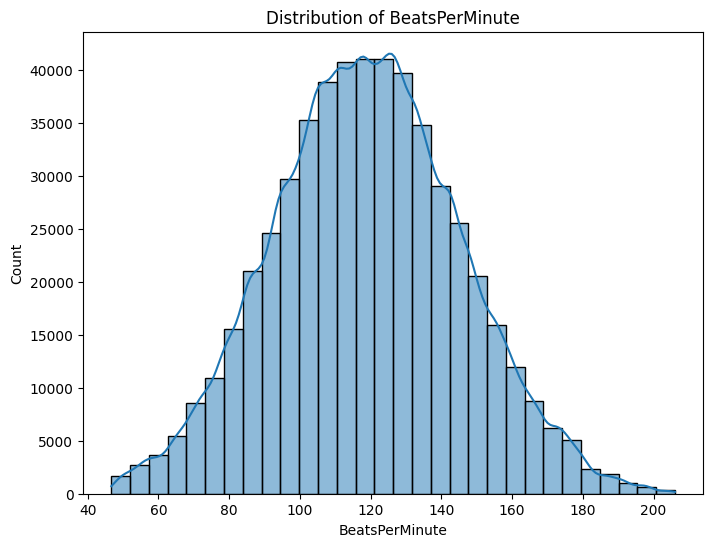

In [8]:
# Target Variable Analysis

plt.figure(figsize=(8, 6))

sns.histplot(train_data['BeatsPerMinute'], kde=True, bins=30)
plt.title("Distribution of BeatsPerMinute")
plt.show()

In [9]:
train_data.isnull().sum()

RhythmScore                  0
AudioLoudness                0
VocalContent                 0
AcousticQuality              0
InstrumentalScore            0
LivePerformanceLikelihood    0
MoodScore                    0
TrackDurationMs              0
Energy                       0
BeatsPerMinute               0
dtype: int64

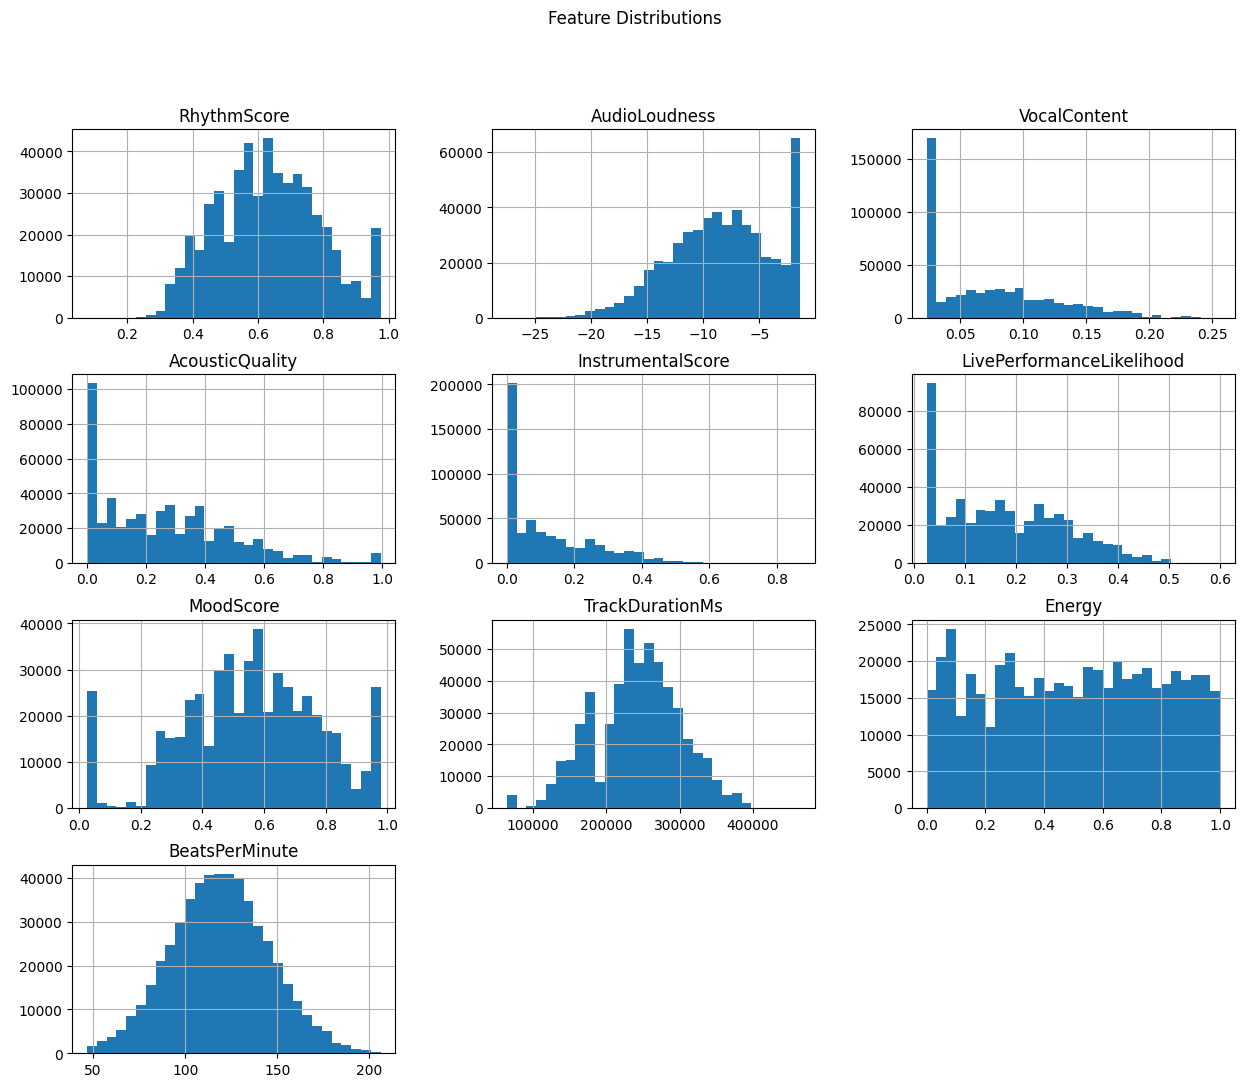

In [10]:
# Feature Distribution

numeric_features = train_data.select_dtypes(include=[np.number]).columns.tolist()

train_data[numeric_features].hist(bins=30, figsize=(15,12), layout=(4,3))
plt.suptitle("Feature Distributions")
plt.show()

In [11]:
correlation_matrix = train_data.corr()

In [12]:
correlation_matrix

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
RhythmScore,1.000000,-0.017385,0.008737,0.028203,0.010992,0.031535,-0.008946,-0.017640,-0.147350,0.005440
AudioLoudness,-0.017385,1.000000,-0.009357,-0.013019,0.003772,-0.021620,-0.027305,0.004510,0.192411,-0.003327
VocalContent,0.008737,-0.009357,1.000000,0.009370,-0.017739,-0.120294,0.058675,0.018179,0.016124,0.004876
AcousticQuality,0.028203,-0.013019,0.009370,1.000000,0.003247,0.009678,0.037047,-0.022524,-0.418184,-0.000820
InstrumentalScore,0.010992,0.003772,-0.017739,0.003247,1.000000,-0.002403,0.004738,0.009340,-0.019834,0.001900
LivePerformanceLikelihood,0.031535,-0.021620,-0.120294,0.009678,-0.002403,1.000000,0.015461,0.005179,-0.266256,0.003471
MoodScore,-0.008946,-0.027305,0.058675,0.037047,0.004738,0.015461,1.000000,-0.014803,-0.241713,0.007059
TrackDurationMs,-0.017640,0.004510,0.018179,-0.022524,0.009340,0.005179,-0.014803,1.000000,0.048597,0.006637
Energy,-0.147350,0.192411,0.016124,-0.418184,-0.019834,-0.266256,-0.241713,0.048597,1.000000,-0.004375
BeatsPerMinute,0.005440,-0.003327,0.004876,-0.000820,0.001900,0.003471,0.007059,0.006637,-0.004375,1.000000


<Axes: >

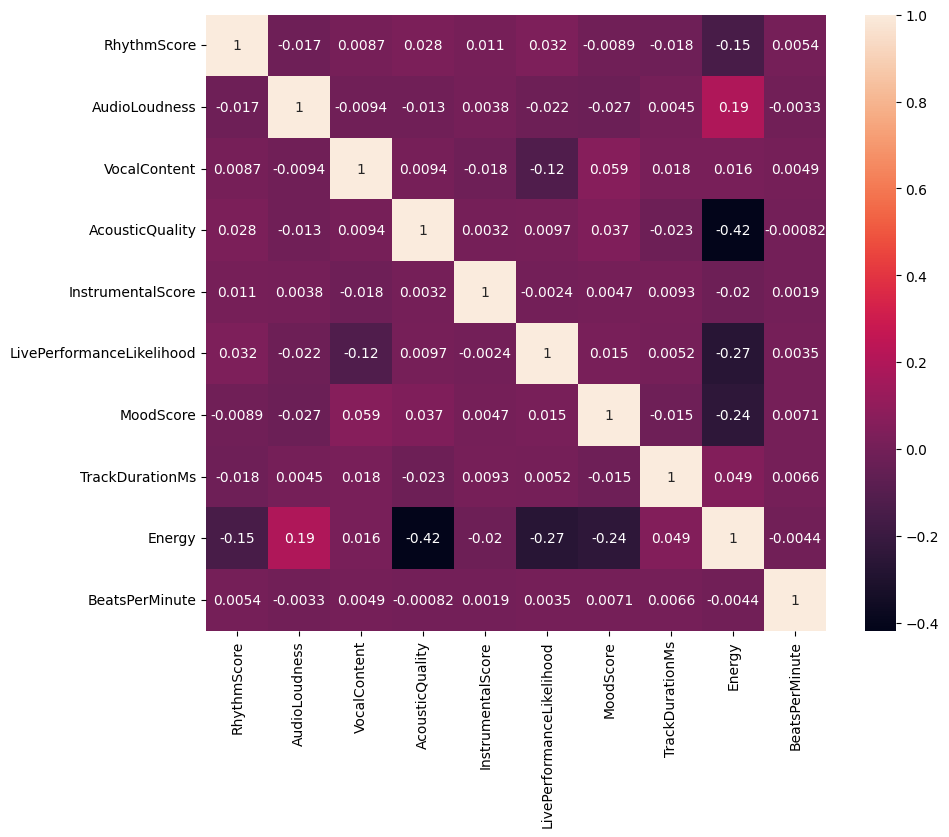

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True)

In [14]:
print("\nCorrelation of each feature with Target (BeatsPerMinutes) feature")
correlation_matrix["BeatsPerMinute"].sort_values(ascending=False)


Correlation of each feature with Target (BeatsPerMinutes) feature


BeatsPerMinute               1.000000
MoodScore                    0.007059
TrackDurationMs              0.006637
RhythmScore                  0.005440
VocalContent                 0.004876
LivePerformanceLikelihood    0.003471
InstrumentalScore            0.001900
AcousticQuality             -0.000820
AudioLoudness               -0.003327
Energy                      -0.004375
Name: BeatsPerMinute, dtype: float64

In [15]:
train_data = train_data.reset_index().drop('id', axis=1)

In [23]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

X = train_data.drop(columns = ['BeatsPerMinute'])
y = train_data["BeatsPerMinute"]

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.20, random_state=42)


In [17]:
from sklearn.linear_model import LinearRegression

linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)

LinearRegression()

In [18]:
train_pred = linear_reg.predict(X_train)

In [19]:
valid_pred = linear_reg.predict(X_valid)

In [20]:
# Training Evaluation

rmse = np.sqrt(mean_squared_error(y_train, train_pred))
mae = mean_absolute_error(y_train, train_pred)
r2 = r2_score(y_train, train_pred)

print(f"Training Evalutation\n\nRMSE Score : {rmse},\nMAE Score: {mae},\nR-Squared: {r2} ")

Training Evalutation

RMSE Score : 26.47128080756828,
MAE Score: 21.20108864902055,
R-Squared: 0.00018530088221113683 


In [21]:
# Validation Evaluation 

rmse_valid = np.sqrt(mean_squared_error(y_valid, valid_pred))
mae = mean_absolute_error(y_valid, valid_pred)
r2 = r2_score(y_valid, valid_pred)

print(f"Validation Evalutation\n\nRMSE Score : {rmse},\nMAE Score: {mae},\nR-Squared: {r2} ")

Validation Evalutation

RMSE Score : 26.47128080756828,
MAE Score: 21.184139341459268,
R-Squared: 9.495687914706785e-05 


It is evident here that the linear model is unable to capture any useful information from the given dataset. The correlation analysis also suggested that features don't have any linear relationship among them. Hence, as a next step trying to fit a non-linear model that can capture the relationship better.

In [24]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(random_state=42)

param_list = {
    'n_estimators':[200, 500],      # number of boosting rounds (trees)
    'learning_rate':[0.01, 0.05, 0.1],    # step size shrinkage
    'subsample':[0.6, 1.0],         # fraction of samples used per tree
    'colsample_bytree':[0.7, 1.0],
}

random_search = RandomizedSearchCV(
estimator=xgb_model,
param_distributions=param_list,
n_iter=20,
scoring='neg_mean_squared_error',
cv=3,
verbose=1,
n_jobs=2,
random_state=42
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          gamma=None, grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=...
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None,
                                          random_state=42, ...),
                   n_iter=20, n_jobs=2,
                   param_distributions={'colsample_bytree': [0.7, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'n_estimators': [200, 500],
                                        'subsample': [0.6, 1.0]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=1)

In [25]:
print("Best parameters:", random_search.best_params_)

Best parameters: {'subsample': 0.6, 'n_estimators': 200, 'learning_rate': 0.01, 'colsample_bytree': 1.0}


In [26]:
best_model = random_search.best_estimator_

In [27]:
best_model_valid_pred = best_model.predict(X_valid)

In [28]:
rmse_valid = np.sqrt(mean_squared_error(y_valid, best_model_valid_pred))
mae = mean_absolute_error(y_valid, best_model_valid_pred)
r2 = r2_score(y_valid, best_model_valid_pred)

print(f"Validation Evalutation for XGBoost\n\nRMSE Score : {rmse},\nMAE Score: {mae},\nR-Squared: {r2} ")

Validation Evalutation for XGBoost

RMSE Score : 26.47128080756828,
MAE Score: 21.181357545589485,
R-Squared: 0.0005216772889619081 


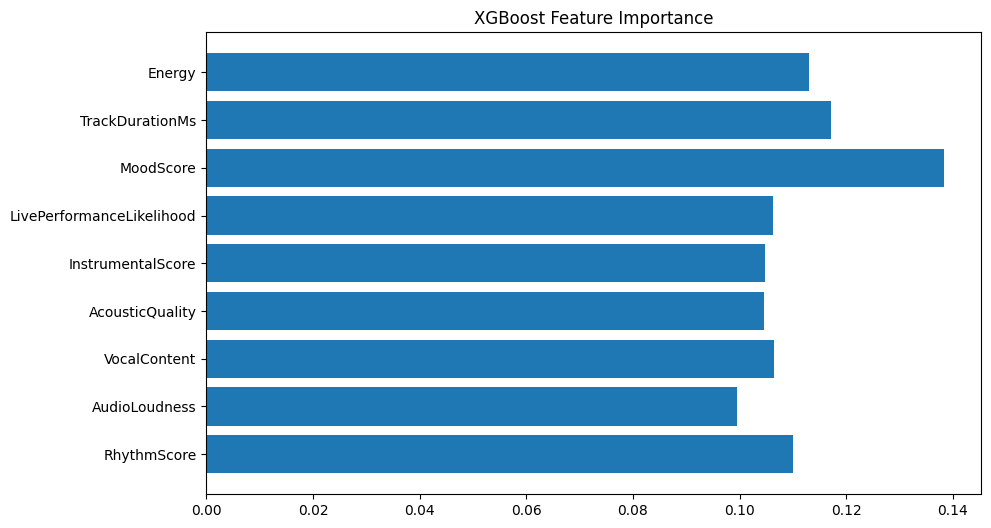

In [29]:
plt.figure(figsize=(10,6))
plt.barh(X.columns, best_model.feature_importances_)
plt.title("XGBoost Feature Importance")
plt.show()

In [30]:
test_data = pd.read_csv("/kaggle/input/playground-series-s5e9/test.csv", index_col=0)

In [31]:
test_data.head()

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy
id,,,,,,,,,
524164,0.410013,-16.794967,0.023500,0.232910,0.012689,0.271585,0.664321,302901.5498,0.424867
524165,0.463071,-1.357000,0.141818,0.057725,0.257942,0.097624,0.829552,221995.6643,0.846000
524166,0.686569,-3.368928,0.167851,0.287823,0.210915,0.325909,0.304978,357724.0127,0.134067
524167,0.885793,-5.598049,0.118488,0.000005,0.376906,0.134435,0.487740,271790.3989,0.316467
524168,0.637391,-7.068160,0.126099,0.539073,0.068950,0.024300,0.591248,277728.5383,0.481067


In [32]:
X_test = test_data.reset_index().drop('id', axis=1)

In [33]:
y_pred_test = best_model.predict(X_test)

In [35]:
output = pd.DataFrame({
    "id": test_data.index,
    "Predicted_BPM": y_pred_test
})

output.to_csv("submission.csv", index=False)


In [36]:
output.head()

,id,Predicted_BPM
0,524164,118.988937
1,524165,118.876328
2,524166,119.189857
3,524167,119.244873
4,524168,119.580162
